# E-Commerce Customer Lifetime Value (CLV) Prediction Model

**Project:** IBM SkillsBuild Data Analytics with AI Academic Internship Program (BharatCares x AICTE)

**Author:** Avantika

**Objective:** Build and evaluate machine learning regression models that predict a customer's **Customer Lifetime Value (CLV)** from order-level e-commerce transaction data (order, customer, payment and profitability attributes). Accurate CLV prediction helps a business identify high-value customers, target retention campaigns, and allocate marketing spend more effectively.

**Dataset:** `ecommerce_sales_customer_analytics_150k-selected-columns.csv` — order-level e-commerce sales & customer analytics data (order details, customer demographics, payment info, returns, profitability, and customer lifetime value).

## 1. Import Libraries

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

RANDOM_STATE = 42

##  Load Dataset

In [34]:
df = pd.read_csv('ecommerce_sales_customer_analytics_150k-selected-columns (2).csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (66849, 25)


,order_id,order_date,order_time,order_status,sales_channel,customer_id,customer_name,customer_age,gender,customer_segment,...,discount_amount,tax_amount,shipping_cost,net_sales,product_cost,profit,profit_margin_percentage,customer_lifetime_value,is_repeat_customer,customer_order_count
0,ORD-301242,2023-11-06,16:37:47,Completed,Mobile App,CUST-003102,Jasmine Ryan,55,Male,Consumer,...,477.89,61.07,12.03,945.40,588.33,345.04,36.50,12459.68,True,11
1,ORD-773460,2025-12-24,01:22:36,Completed,Website,CUST-003124,Scott Chase,26,Male,Premium,...,1456.06,320.83,9.00,2018.41,2031.88,-22.47,-1.11,13032.48,True,11
2,ORD-449374,2021-07-05,14:24:21,Completed,Mobile App,CUST-012496,Marc Wheeler,69,Female,Premium,...,97.30,29.79,13.05,468.35,257.73,197.57,42.18,6159.44,True,6
3,ORD-567636,2023-01-21,07:20:26,Completed,Social Media,CUST-023928,Jennifer Smith,65,Male,Consumer,...,53.34,34.39,20.85,546.52,277.84,247.83,45.35,5638.30,True,7
4,ORD-820028,2022-05-13,09:46:21,Completed,Social Media,CUST-012730,Jessica Wang,34,Female,Consumer,...,133.63,421.35,23.03,2785.27,1231.88,1530.36,54.94,13240.10,True,8


In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 66849 entries, 0 to 66848
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   order_id                  66849 non-null  str    
 1   order_date                66849 non-null  str    
 2   order_time                66849 non-null  str    
 3   order_status              66849 non-null  str    
 4   sales_channel             66849 non-null  str    
 5   customer_id               66849 non-null  str    
 6   customer_name             66849 non-null  str    
 7   customer_age              66849 non-null  int64  
 8   gender                    66849 non-null  str    
 9   customer_segment          66849 non-null  str    
 10  payment_method            66849 non-null  str    
 11  payment_status            66849 non-null  str    
 12  currency                  66849 non-null  str    
 13  return_status             4551 non-null   str    
 14  return_reason    

In [36]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,66849,66849,ORD-301242,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_date,66849,1826,2025-12-10,71,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_time,66849,46635,08:49:28,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_status,66849,4,Completed,55034,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sales_channel,66849,4,Mobile App,26886,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,66849,23248,CUST-022255,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_name,66849,20277,John Smith,55,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_age,66849.0,NaN,NaN,NaN,45.824754,16.463178,18.0,32.0,46.0,60.0,74.0
gender,66849,3,Male,32257,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_segment,66849,4,Consumer,36579,NaN,NaN,NaN,NaN,NaN,NaN,NaN


##  Data Cleaning & Exploration

In [37]:
# Check missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing)

# return_status / return_reason are NaN for non-returned orders -- this is expected (not a data quality issue)
df['return_status'] = df['return_status'].fillna('Not Returned')
df['return_reason'] = df['return_reason'].fillna('Not Applicable')

# Check duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Columns with missing values:
return_status    62298
return_reason    62298
dtype: int64

Duplicate rows: 0


In [38]:
df['order_status'].value_counts()

order_status
Completed    55034
Returned      4551
Cancelled     4047
Pending       3217
Name: count, dtype: int64

###  Target Variable: Customer Lifetime Value (CLV)

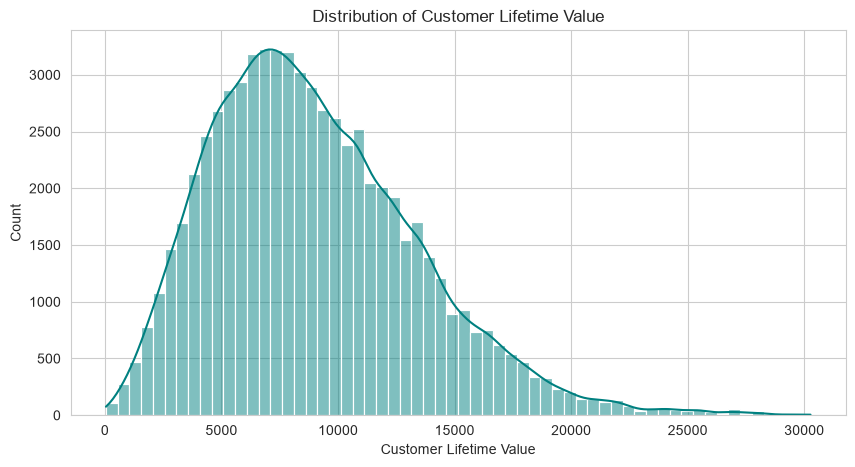

count    66849.000000
mean      8974.009871
std       4426.247458
min         44.500000
25%       5719.310000
50%       8384.930000
75%      11665.920000
max      30268.440000
Name: customer_lifetime_value, dtype: float64


In [39]:
plt.figure(figsize=(10,5))
sns.histplot(df['customer_lifetime_value'], bins=60, kde=True, color='teal')
plt.title('Distribution of Customer Lifetime Value')
plt.xlabel('Customer Lifetime Value')
plt.show()

print(df['customer_lifetime_value'].describe())

###  Key Relationships

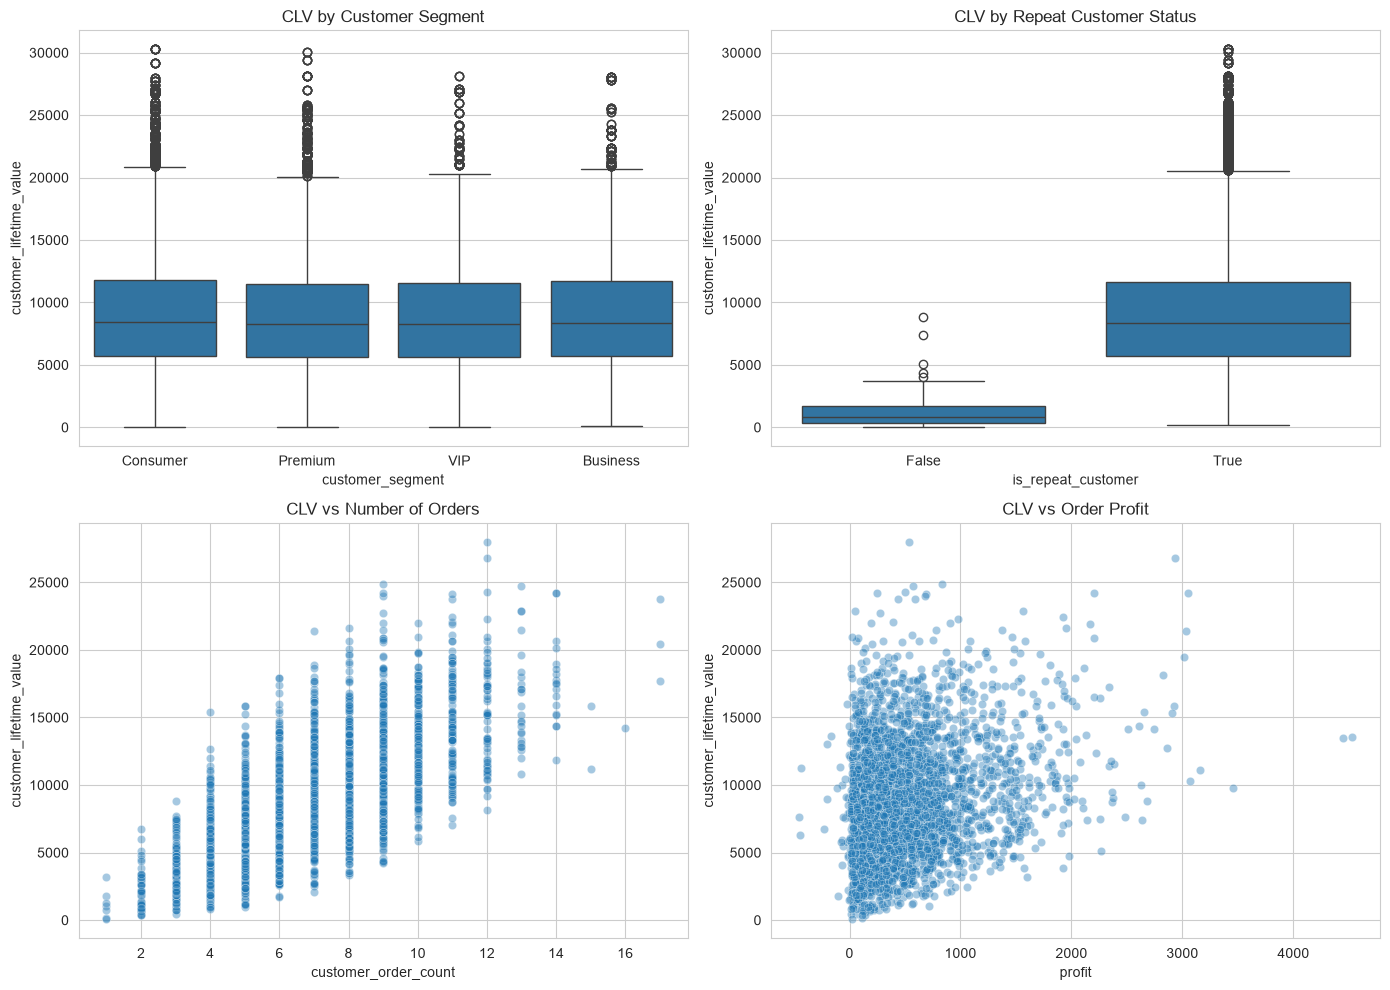

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=df, x='customer_segment', y='customer_lifetime_value', ax=axes[0,0])
axes[0,0].set_title('CLV by Customer Segment')

sns.boxplot(data=df, x='is_repeat_customer', y='customer_lifetime_value', ax=axes[0,1])
axes[0,1].set_title('CLV by Repeat Customer Status')

sns.scatterplot(data=df.sample(3000, random_state=RANDOM_STATE), x='customer_order_count',
                 y='customer_lifetime_value', alpha=0.4, ax=axes[1,0])
axes[1,0].set_title('CLV vs Number of Orders')

sns.scatterplot(data=df.sample(3000, random_state=RANDOM_STATE), x='profit',
                 y='customer_lifetime_value', alpha=0.4, ax=axes[1,1])
axes[1,1].set_title('CLV vs Order Profit')

plt.tight_layout()
plt.show()

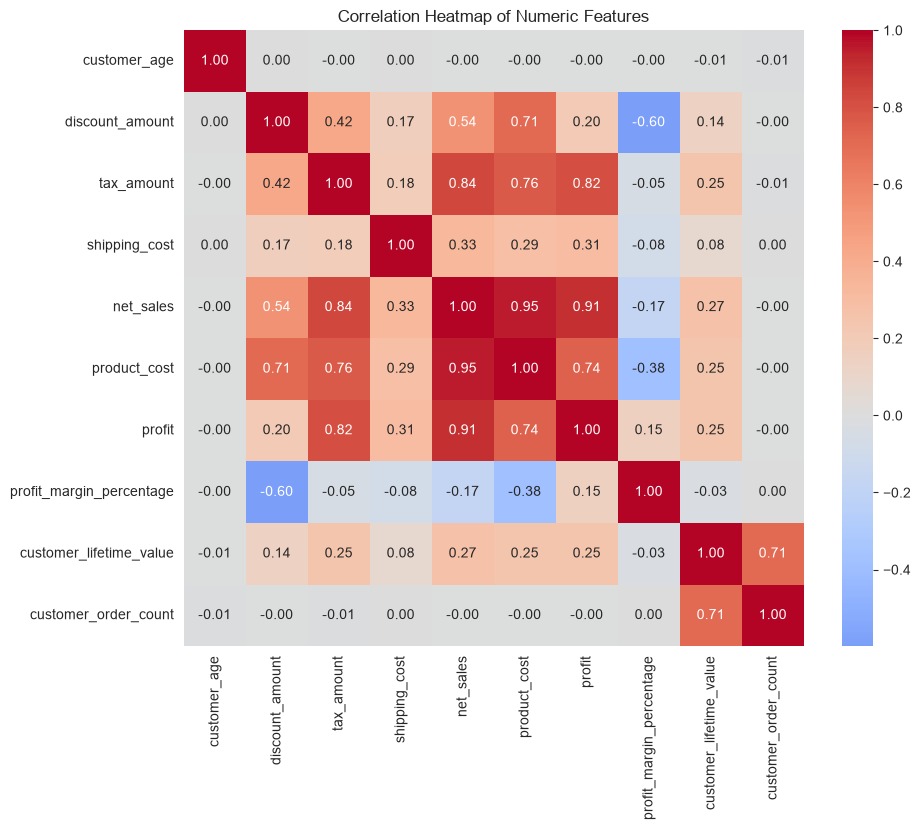

In [41]:
numeric_cols = ['customer_age','discount_amount','tax_amount','shipping_cost','net_sales',
                 'product_cost','profit','profit_margin_percentage','customer_lifetime_value',
                 'customer_order_count']
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

##  Feature Engineering

In [42]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['order_year'] = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month
df['order_dayofweek'] = df['order_date'].dt.dayofweek  # 0=Monday
df['order_hour'] = pd.to_datetime(df['order_time'], format='%H:%M:%S').dt.hour

df.head()

,order_id,order_date,order_time,order_status,sales_channel,customer_id,customer_name,customer_age,gender,customer_segment,...,product_cost,profit,profit_margin_percentage,customer_lifetime_value,is_repeat_customer,customer_order_count,order_year,order_month,order_dayofweek,order_hour
0,ORD-301242,2023-11-06,16:37:47,Completed,Mobile App,CUST-003102,Jasmine Ryan,55,Male,Consumer,...,588.33,345.04,36.50,12459.68,True,11,2023,11,0,16
1,ORD-773460,2025-12-24,01:22:36,Completed,Website,CUST-003124,Scott Chase,26,Male,Premium,...,2031.88,-22.47,-1.11,13032.48,True,11,2025,12,2,1
2,ORD-449374,2021-07-05,14:24:21,Completed,Mobile App,CUST-012496,Marc Wheeler,69,Female,Premium,...,257.73,197.57,42.18,6159.44,True,6,2021,7,0,14
3,ORD-567636,2023-01-21,07:20:26,Completed,Social Media,CUST-023928,Jennifer Smith,65,Male,Consumer,...,277.84,247.83,45.35,5638.30,True,7,2023,1,5,7
4,ORD-820028,2022-05-13,09:46:21,Completed,Social Media,CUST-012730,Jessica Wang,34,Female,Consumer,...,1231.88,1530.36,54.94,13240.10,True,8,2022,5,4,9


##  Preprocessing

We select the features that are available at (or near) order time and are meaningful predictors of a customer's lifetime value, encode categorical variables, and split the data into training and test sets.

In [43]:
feature_cols = ['customer_age', 'gender', 'customer_segment', 'payment_method',
                 'payment_status', 'sales_channel', 'currency', 'discount_amount',
                 'tax_amount', 'shipping_cost', 'net_sales', 'product_cost', 'profit',
                 'profit_margin_percentage', 'is_repeat_customer', 'customer_order_count',
                 'order_year', 'order_month', 'order_dayofweek', 'order_hour']

target_col = 'customer_lifetime_value'

X = df[feature_cols].copy()
y = df[target_col].copy()

categorical_cols = X.select_dtypes(include=['object', 'bool']).columns.tolist()
print("Categorical columns to encode:", categorical_cols)

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

X.head()

Categorical columns to encode: ['gender', 'customer_segment', 'payment_method', 'payment_status', 'sales_channel', 'currency', 'is_repeat_customer']


,customer_age,gender,customer_segment,payment_method,payment_status,sales_channel,currency,discount_amount,tax_amount,shipping_cost,net_sales,product_cost,profit,profit_margin_percentage,is_repeat_customer,customer_order_count,order_year,order_month,order_dayofweek,order_hour
0,55,1,1,5,1,1,6,477.89,61.07,12.03,945.40,588.33,345.04,36.50,1,11,2023,11,0,16
1,26,1,2,4,2,3,3,1456.06,320.83,9.00,2018.41,2031.88,-22.47,-1.11,1,11,2025,12,2,1
2,69,0,2,2,1,1,6,97.30,29.79,13.05,468.35,257.73,197.57,42.18,1,6,2021,7,0,14
3,65,1,1,4,1,2,6,53.34,34.39,20.85,546.52,277.84,247.83,45.35,1,7,2023,1,5,7
4,34,0,1,5,1,2,5,133.63,421.35,23.03,2785.27,1231.88,1530.36,54.94,1,8,2022,5,4,9


In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)

# Scaled versions (needed for Linear Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

Training set: (53479, 20), Test set: (13370, 20)


## 6. Model Training

We train and compare three regression models:
1. **Linear Regression** — simple, interpretable baseline
2. **Random Forest Regressor** — ensemble of decision trees, handles non-linearity well
3. **Gradient Boosting Regressor** — sequential boosted ensemble, typically strong on tabular data

In [45]:
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2 Score': r2}

results = []
trained_models = {}
predictions = {}

In [46]:
# 1. Linear Regression (uses scaled features)
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)

results.append(evaluate_model('Linear Regression', y_test, lr_preds))
trained_models['Linear Regression'] = lr
predictions['Linear Regression'] = lr_preds

In [47]:
# 2. Random Forest Regressor
rf = RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_leaf=3,
                            random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

results.append(evaluate_model('Random Forest', y_test, rf_preds))
trained_models['Random Forest'] = rf
predictions['Random Forest'] = rf_preds

In [48]:
# 3. Gradient Boosting Regressor
gb = GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.1,
                                random_state=RANDOM_STATE)
gb.fit(X_train, y_train)
gb_preds = gb.predict(X_test)

results.append(evaluate_model('Gradient Boosting', y_test, gb_preds))
trained_models['Gradient Boosting'] = gb
predictions['Gradient Boosting'] = gb_preds

##  Model Evaluation & Comparison

In [49]:
results_df = pd.DataFrame(results).sort_values('R2 Score', ascending=False).reset_index(drop=True)
results_df

,Model,MAE,RMSE,R2 Score
0,Gradient Boosting,2183.316252,2839.911116,0.584626
1,Random Forest,2189.970229,2848.809587,0.582019
2,Linear Regression,2189.280021,2852.068975,0.581062


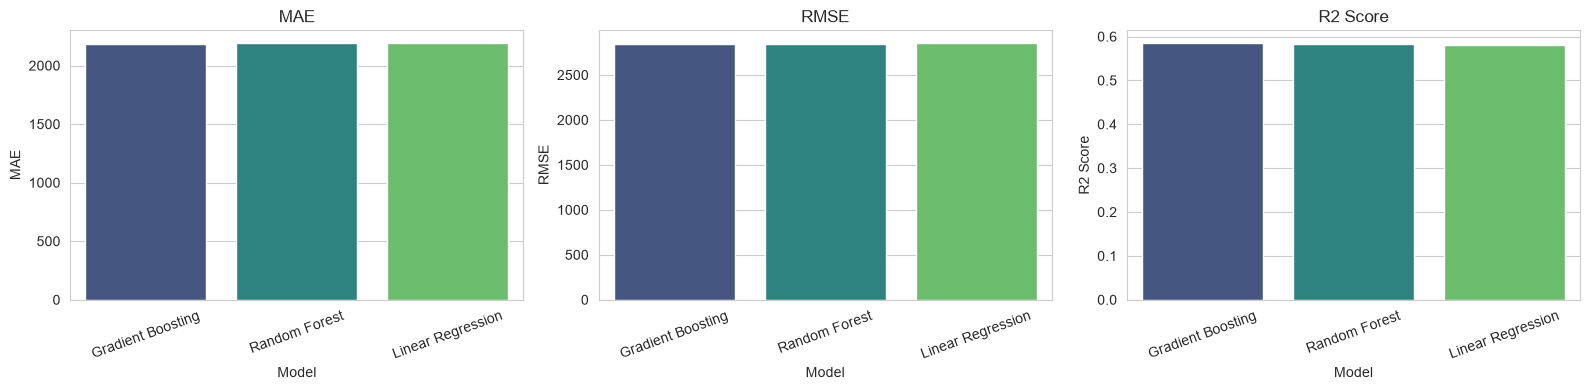

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
metrics = ['MAE', 'RMSE', 'R2 Score']
for ax, metric in zip(axes, metrics):
    sns.barplot(data=results_df, x='Model', y=metric, ax=ax, palette='viridis')
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

Best model: Gradient Boosting


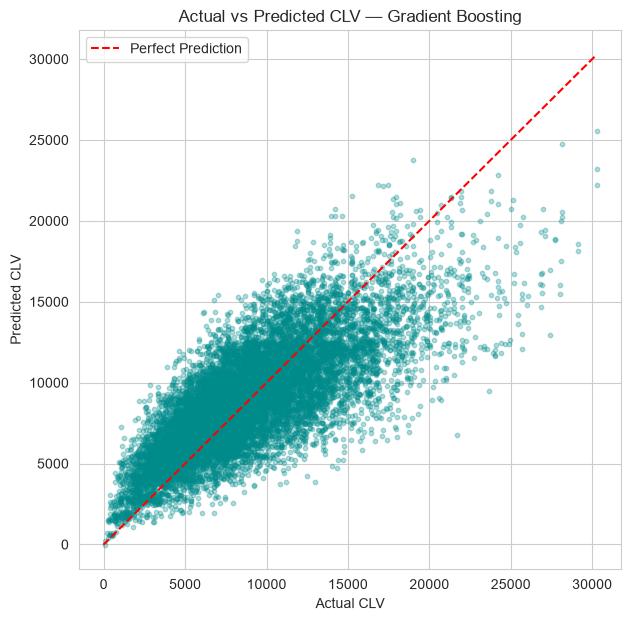

In [51]:
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
best_preds = predictions[best_model_name]
print(f"Best model: {best_model_name}")

plt.figure(figsize=(7,7))
plt.scatter(y_test, best_preds, alpha=0.3, s=10, color='darkcyan')
lims = [min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())]
plt.plot(lims, lims, 'r--', label='Perfect Prediction')
plt.xlabel('Actual CLV')
plt.ylabel('Predicted CLV')
plt.title(f'Actual vs Predicted CLV — {best_model_name}')
plt.legend()
plt.show()

###  Feature Importance

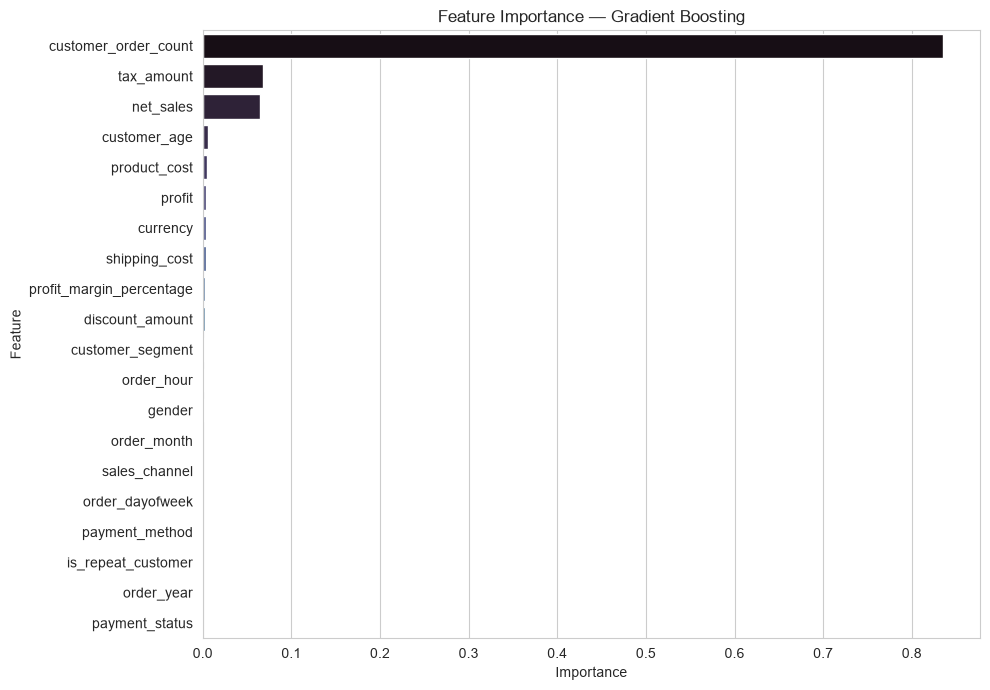

In [52]:
if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(10,7))
    sns.barplot(data=importance_df, x='Importance', y='Feature', palette='mako')
    plt.title(f'Feature Importance — {best_model_name}')
    plt.tight_layout()
    plt.show()

    importance_df
else:
    print("Selected model does not expose feature_importances_ (e.g. Linear Regression).")

##  Save the Trained Model

We persist the best-performing model (and the preprocessing objects needed to reuse it) to disk with `joblib`, so it can be loaded and used for inference without retraining.

In [53]:
joblib.dump(best_model, 'best_clv_model.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')
joblib.dump(feature_cols, 'feature_columns.pkl')

print("Model and preprocessing artifacts saved:")
print(" - best_clv_model.pkl")
print(" - feature_scaler.pkl")
print(" - label_encoders.pkl")
print(" - feature_columns.pkl")

Model and preprocessing artifacts saved:
 - best_clv_model.pkl
 - feature_scaler.pkl
 - label_encoders.pkl
 - feature_columns.pkl


##  Making Predictions on New Data

In [54]:
def predict_clv(new_order: dict, model=best_model, encoders=label_encoders, cols=feature_cols):
    """Predict Customer Lifetime Value for a single new order (as a dict of raw feature values)."""
    row = pd.DataFrame([new_order])[cols].copy()
    for col, le in encoders.items():
        if col in row.columns:
            row[col] = le.transform(row[col].astype(str))
    return model.predict(row)[0]

# Example usage
sample_order = {
    'customer_age': 34, 'gender': 'Female', 'customer_segment': 'Premium',
    'payment_method': 'Credit Card', 'payment_status': 'Paid', 'sales_channel': 'Website',
    'currency': 'USD', 'discount_amount': 50.0, 'tax_amount': 40.0, 'shipping_cost': 10.0,
    'net_sales': 800.0, 'product_cost': 500.0, 'profit': 300.0, 'profit_margin_percentage': 37.5,
    'is_repeat_customer': True, 'customer_order_count': 8, 'order_year': 2025,
    'order_month': 6, 'order_dayofweek': 2, 'order_hour': 14
}

predicted_clv = predict_clv(sample_order)
print(f"Predicted Customer Lifetime Value: {predicted_clv:.2f}")

Predicted Customer Lifetime Value: 9282.89


##  Conclusion

- We built and compared three regression models (Linear Regression, Random Forest, Gradient Boosting) to predict **Customer Lifetime Value** from e-commerce order and customer data.
- The best-performing model was **selected automatically based on R² score** on the held-out test set (see Section 7).
- **Profit, net sales, and number of past orders** were among the strongest predictors of CLV (see feature importance chart).
- This model can help the business **prioritize marketing spend and retention efforts** on customers predicted to have high lifetime value.

### Possible Future Improvements
- Hyperparameter tuning with `GridSearchCV` / `RandomizedSearchCV`
- Try gradient boosting libraries such as XGBoost / LightGBM
- Add customer-level aggregated features (e.g. average order value, return rate)
- Deploy the saved model behind an API for real-time CLV scoring